# Établissements Hospitaliers Franciliens - EDA & Cleaning

This notebook performs exploratory data analysis and data cleaning on the healthcare facilities dataset from Île-de-France region.

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import re

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set plot style
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 2. Load Data

In [5]:
# Load the hospital data
df = pd.read_csv('data/bronze/public_service_data/les_etablissements_hospitaliers_franciliens.csv',
                 sep=';',  # French CSV often uses semicolon
                 encoding='utf-8',
                 low_memory=False)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset loaded successfully!
Shape: 1,223 rows × 31 columns
Memory usage: 1.60 MB


## 3. Initial Data Inspection

In [30]:
# Display first rows
print("FIRST 10 ROWS")
display(df.head(10))

FIRST 10 ROWS


,finess_et,finess_ej,raison_sociale,raison_sociale_entite_juridique,adresse_administrative_1,adresse_administrative_2,num_voie,cpt_num,type_voie,voie,adresse_complete,complement_adresse,num_dept,dept,cp_ville,num_tel,num_fax,num_cat,categorie_de_l_etablissement,num_type,type_etablissement,num_siret,code_ape,code_tarif,lib_tarification,code_psph,participant_service_public_hospitalier,date_ouverture,lat,lng,wgs84,date_ouverture_dt,year_ouverture,decade_ouverture,lat_num,lng_num
0,780420048,780021069,REPOS ET CONVALESCENCE L'OASIS,NaN,NaN,NaN,NaN,NaN,R,LAMARTINE,R LAMARTINE,NaN,78,YVELINES,78470 ST REMY LES CHEVREUSE,01 30 47 80 00,01 30 47 80 12,108,Etablissement de Convalescence et de Repos,1107,Etablissements de Soins de Suite et de Réadapt...,4.445168e+13,8610Z,7,ARS établissements de santé non financés dotat...,0.0,Non concerné,1946-01-05,48.711967,2.068011,"48.7119665,2.0680105",1946-01-05,1946,1940,48.711967,2.068011
1,780017901,780140059,CENTRE ARMAGIS,NaN,NaN,NaN,9.0,NaN,R,ARMAGIS,9 R ARMAGIS,NaN,78,YVELINES,78100 ST GERMAIN EN LAYE,01 39 21 14 35,NaN,156,Centre Médico-Psychologique (C.M.P.),1111,Autres Etablissements de Lutte contre les Mala...,NaN,NaN,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,1997-01-01,48.897809,2.085892,"48.8978094,2.0858916",1997-01-01,1997,1990,48.897809,2.085892
2,780018289,780110078,CMP ADOLESCENTS 78I06,NaN,NaN,NaN,11.0,B,R,JOUVENCEL,11B R JOUVENCEL,NaN,78,YVELINES,78000 VERSAILLES,01 39 63 90 91,NaN,156,Centre Médico-Psychologique (C.M.P.),1111,Autres Etablissements de Lutte contre les Mala...,NaN,NaN,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,2007-01-29,48.803140,2.133176,"48.8031397,2.1331757",2007-01-29,2007,2000,48.803140,2.133176
3,950006619,950110015,CENTRE DE JOUR DU FIEF,NaN,NaN,NaN,45.0,NaN,R,DU FIEF,45 R DU FIEF,NaN,95,VAL-D'OISE,95100 ARGENTEUIL,NaN,NaN,355,Centre Hospitalier (C.H.),1102,Centres Hospitaliers,2.695016e+13,8610Z,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,2005-01-01,48.950513,2.237513,"48.9505132,2.237513",2005-01-01,2005,2000,48.950513,2.237513
4,920812013,780140059,CMP ENFANTS 92I02 (J. PREVERT),CENTRE MEDICO PSYCHOLOGIQUE INFANTO-JUVENILE,NaN,NaN,2.0,NaN,PAS,JACQUES PREVERT,2 PAS JACQUES PREVERT,NaN,92,HAUTS-DE-SEINE,92700 COLOMBES,01 47 82 37 34,01 47 82 88 30,156,Centre Médico-Psychologique (C.M.P.),1111,Autres Etablissements de Lutte contre les Mala...,2.678024e+13,NaN,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,1904-04-04,48.922089,2.252624,"48.9220894,2.252624",1904-04-04,1904,1900,48.922089,2.252624
5,920024676,950140012,CMP ADULTES 92G04 (C. DESMOULIN),NaN,NaN,NaN,7.0,NaN,R,CAMILLE DESMOULIN,7 R CAMILLE DESMOULIN,NaN,92,HAUTS-DE-SEINE,92300 LEVALLOIS PERRET,01 41 34 07 30,NaN,156,Centre Médico-Psychologique (C.M.P.),1111,Autres Etablissements de Lutte contre les Mala...,2.695001e+13,NaN,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,1998-01-01,48.888899,2.284317,"48.8888994,2.2843171",1998-01-01,1998,1990,48.888899,2.284317
6,920810827,940140049,CMP BAGNEUX,NaN,NaN,NaN,64.0,NaN,R,DES MEUNIERS,64 R DES MEUNIERS,NaN,92,HAUTS-DE-SEINE,92220 BAGNEUX,01 46 63 45 50,01 46 63 82 84,156,Centre Médico-Psychologique (C.M.P.),1111,Autres Etablissements de Lutte contre les Mala...,2.692014e+13,8610Z,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,1904-04-04,48.797786,2.315253,"48.7977862,2.3152535",1904-04-04,1904,1900,48.797786,2.315253
7,920002177,920804465,ETABLISSEMENT PUBLIC DE SANTE ERASME,NaN,NaN,NaN,143.0,NaN,AV,ARMAND GUILLEBAUD,143 AV ARMAND GUILLEBAUD,NaN,92,HAUTS-DE-SEINE,92160 ANTONY,01 46 74 33 99,01 46 74 30 08,292,Centre Hospitalier Spécialisé lutte Maladies M...,1103,Centres Hospitaliers Spécialisés Lutte Maladie...,2.692014e+13,8610Z,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public 

In [31]:
# Column names and types
print("COLUMN INFORMATION")
print(f"\nTotal columns: {len(df.columns)}\n")

col_info = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.values,
    'Non_Null': df.count().values,
    'Null_Count': df.isnull().sum().values,
    'Null_%': (df.isnull().sum().values / len(df) * 100).round(2)
})

display(col_info)

COLUMN INFORMATION

Total columns: 36



,Column,Data_Type,Non_Null,Null_Count,Null_%
0,finess_et,int64,1223,0,0.00
1,finess_ej,int64,1223,0,0.00
2,raison_sociale,str,1223,0,0.00
3,raison_sociale_entite_juridique,str,670,553,45.22
4,adresse_administrative_1,str,103,1120,91.58
5,adresse_administrative_2,str,216,1007,82.34
6,num_voie,float64,1156,67,5.48
7,cpt_num,str,57,1166,95.34
8,type_voie,str,1207,16,1.31
9,voie,str,1221,2,0.16


In [32]:
# Detailed info
print("DATASET INFO")
display(df.info())

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1223 entries, 0 to 1222
Data columns (total 36 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   finess_et                               1223 non-null   int64         
 1   finess_ej                               1223 non-null   int64         
 2   raison_sociale                          1223 non-null   str           
 3   raison_sociale_entite_juridique         670 non-null    str           
 4   adresse_administrative_1                103 non-null    str           
 5   adresse_administrative_2                216 non-null    str           
 6   num_voie                                1156 non-null   float64       
 7   cpt_num                                 57 non-null     str           
 8   type_voie                               1207 non-null   str           
 9   voie                                    1221 non-n

None

## 4. Exploratory Data Analysis (EDA)

### 4.1 Missing Values Analysis

In [33]:
# Missing values summary
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
}).sort_values('Missing_Count', ascending=False)

print("MISSING VALUES ANALYSIS")
print(f"\nTotal missing values: {df.isnull().sum().sum():,}\n")
display(missing_summary[missing_summary['Missing_Count'] > 0])

MISSING VALUES ANALYSIS

Total missing values: 6,335



,Column,Missing_Count,Missing_Percentage,Data_Type
cpt_num,cpt_num,1166,95.34,str
complement_adresse,complement_adresse,1157,94.60,str
adresse_administrative_1,adresse_administrative_1,1120,91.58,str
adresse_administrative_2,adresse_administrative_2,1007,82.34,str
code_ape,code_ape,582,47.59,str
raison_sociale_entite_juridique,raison_sociale_entite_juridique,553,45.22,str
num_fax,num_fax,421,34.42,str
num_siret,num_siret,136,11.12,float64
num_tel,num_tel,92,7.52,str
num_voie,num_voie,67,5.48,float64


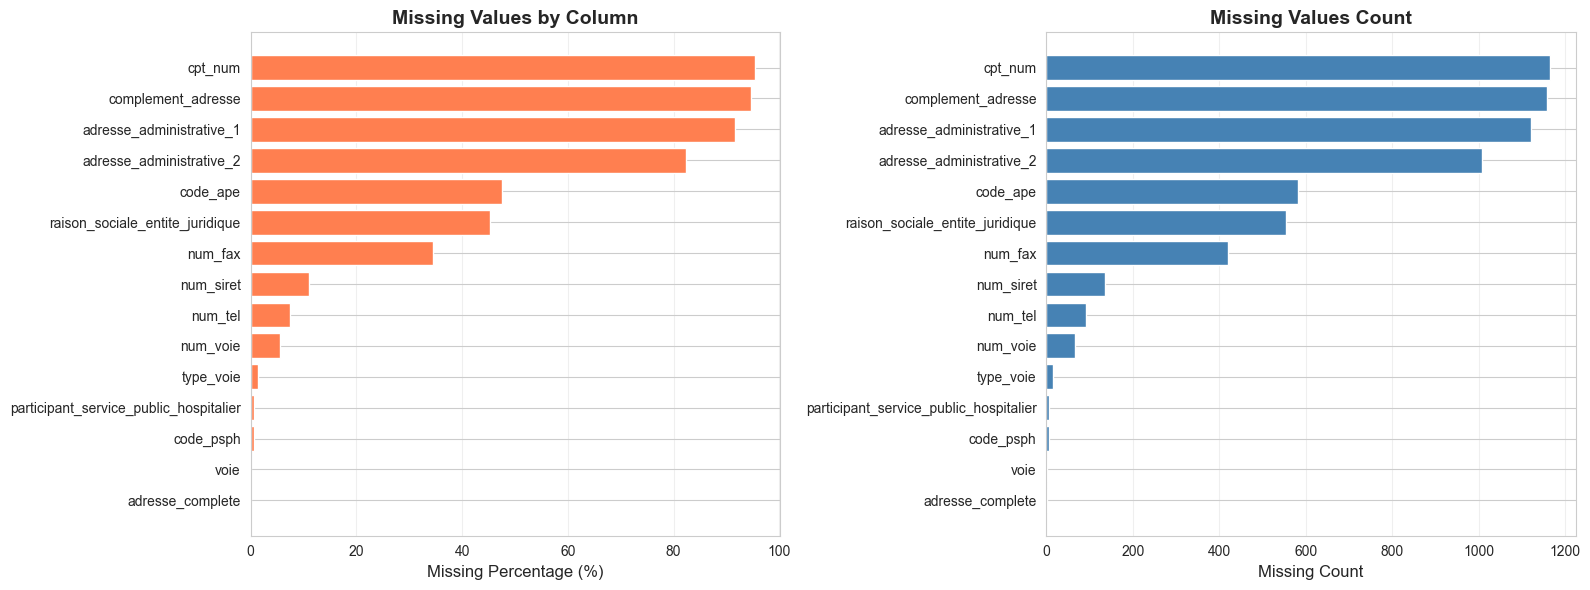

In [10]:
# Visualize missing values
missing_data = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=True)

if len(missing_data) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart
    ax1.barh(missing_data['Column'], missing_data['Missing_Percentage'], color='coral')
    ax1.set_xlabel('Missing Percentage (%)', fontsize=12)
    ax1.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Count chart
    ax2.barh(missing_data['Column'], missing_data['Missing_Count'], color='steelblue')
    ax2.set_xlabel('Missing Count', fontsize=12)
    ax2.set_title('Missing Values Count', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found in the dataset!")

### 4.2 Unique Values & Cardinality

In [34]:
# Unique values analysis
unique_summary = pd.DataFrame({
    'Column': df.columns,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Sample_Value': [str(df[col].dropna().iloc[0]) if len(df[col].dropna()) > 0 else 'N/A' for col in df.columns]
})
unique_summary['Cardinality'] = (unique_summary['Unique_Values'] / len(df) * 100).round(2)

print("UNIQUE VALUES ANALYSIS")
display(unique_summary.sort_values('Unique_Values', ascending=False))

UNIQUE VALUES ANALYSIS


,Column,Unique_Values,Sample_Value,Cardinality
0,finess_et,1223,780420048,100.00
2,raison_sociale,1128,REPOS ET CONVALESCENCE L'OASIS,92.23
10,adresse_complete,1109,R LAMARTINE,90.68
28,lat,1076,48.7119665,87.98
34,lat_num,1076,48.7119665,87.98
30,wgs84,1076,"48.7119665,2.0680105",87.98
29,lng,1075,2.0680105,87.90
35,lng_num,1075,2.0680105,87.90
15,num_tel,1027,01 30 47 80 00,83.97
21,num_siret,1024,44451678500011.0,83.73


### 4.3 Key Categorical Variables Distribution

DISTRIBUTION BY DEPARTMENT (DÉPARTEMENT)
dept
ESSONNE              139
HAUTS-DE-SEINE       193
PARIS                237
SEINE-ET-MARNE       118
SEINE-SAINT-DENIS    155
VAL-D'OISE           112
VAL-DE-MARNE         140
YVELINES             129
Name: count, dtype: int64


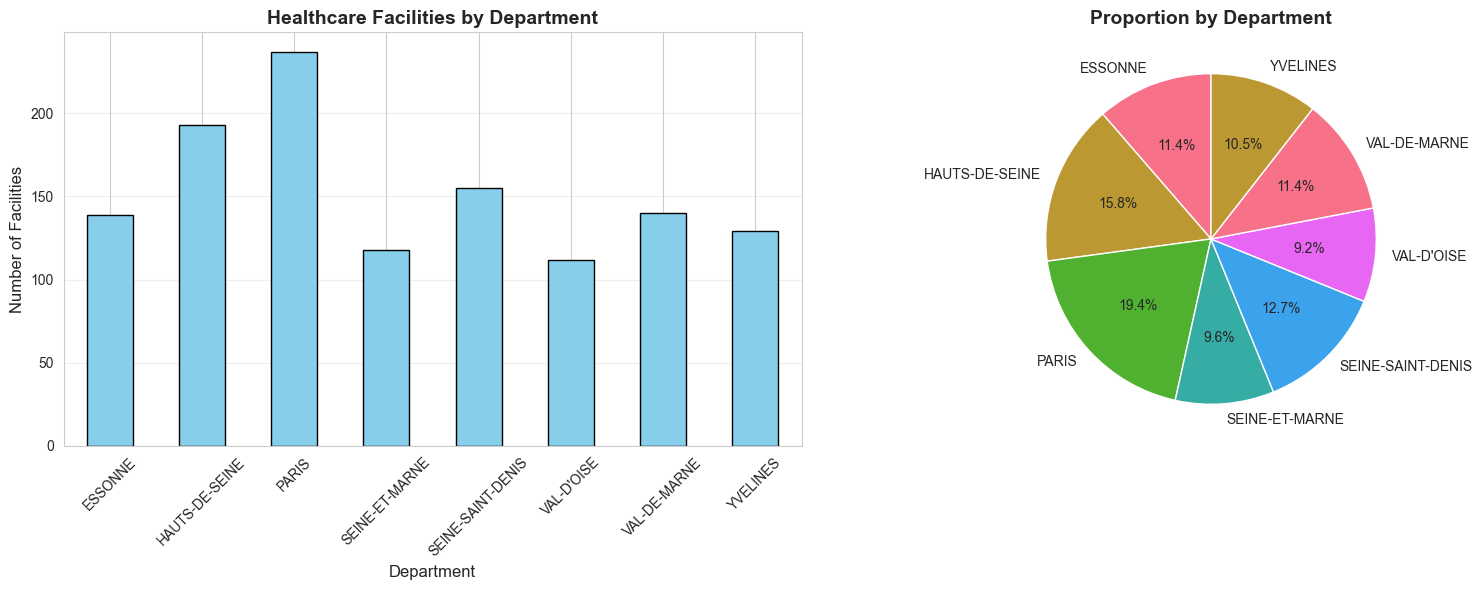

In [35]:
# Department distribution
if 'dept' in df.columns:
    print("DISTRIBUTION BY DEPARTMENT (DÉPARTEMENT)")

    dept_dist = df['dept'].value_counts().sort_index()
    print(dept_dist)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart
    dept_dist.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
    ax1.set_title('Healthcare Facilities by Department', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Department', fontsize=12)
    ax1.set_ylabel('Number of Facilities', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    # Pie chart
    dept_dist.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Proportion by Department', fontsize=14, fontweight='bold')
    ax2.set_ylabel('')
    
    plt.tight_layout()
    plt.show()

DISTRIBUTION BY ESTABLISHMENT CATEGORY
categorie_de_l_etablissement
Centre Médico-Psychologique (C.M.P.)                           375
Centre Hospitalier Spécialisé lutte Maladies Mentales          142
Centre Hospitalier (C.H.)                                      133
Etablissement de Soins Pluridisciplinaire                       99
Centre d'Accueil Thérapeutique à temps partiel (C.A.T.T.P.)     88
Maison de Santé pour Maladies Mentales                          81
Etablissement de Convalescence et de Repos                      52
Centre Hospitalier Régional (C.H.R.)                            52
Etablissement Réadaptation Fonctionnelle                        44
Etablissement de Soins Longue Durée                             40
Etablissement de Soins Chirurgicaux                             33
Appartement Thérapeutique                                       28
Centre Postcure Malades Mentaux                                 13
Etablissement de Soins Médicaux                              

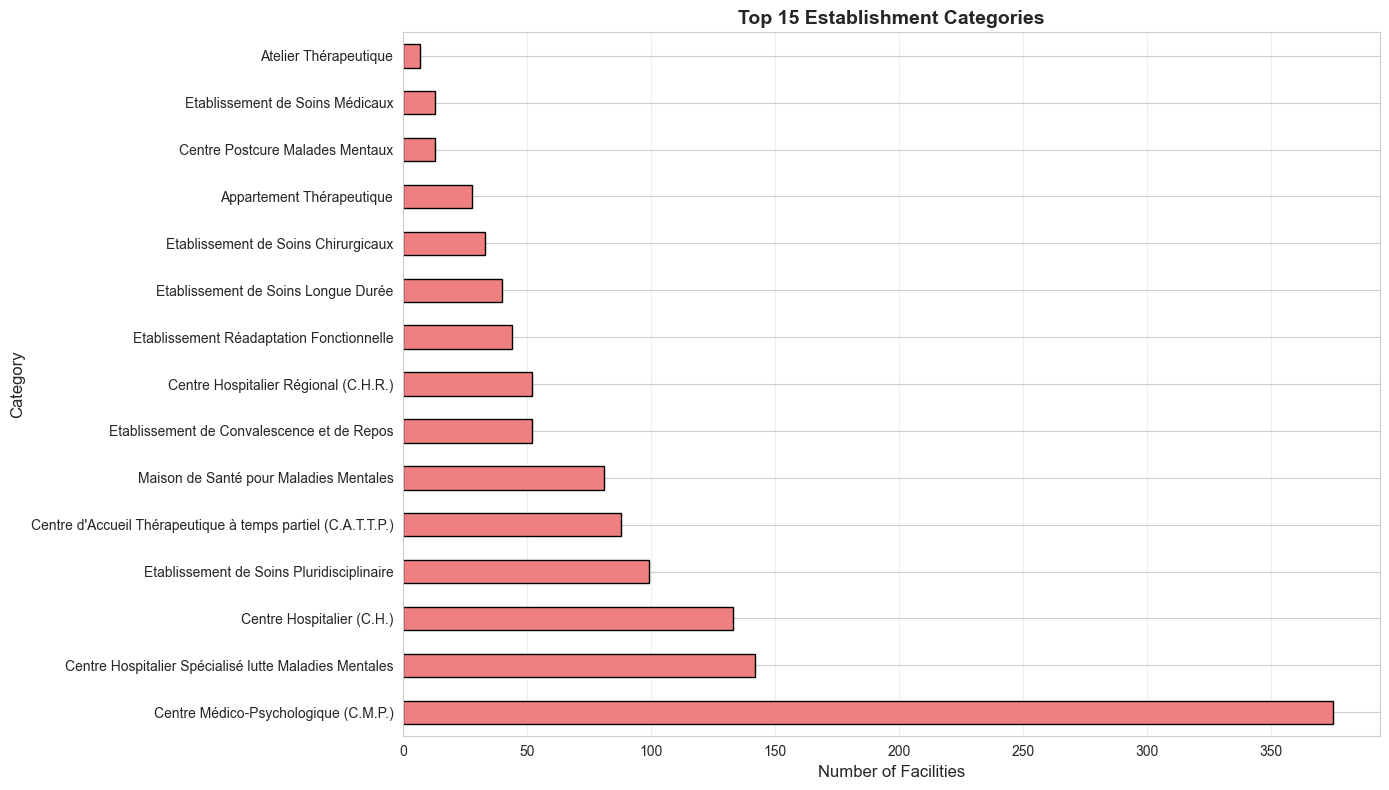

In [13]:
# Category of establishment
if 'categorie_de_l_etablissement' in df.columns:
    print("DISTRIBUTION BY ESTABLISHMENT CATEGORY")

    cat_dist = df['categorie_de_l_etablissement'].value_counts().head(15)
    print(cat_dist)
    
    plt.figure(figsize=(14, 8))
    cat_dist.plot(kind='barh', color='lightcoral', edgecolor='black')
    plt.title('Top 15 Establishment Categories', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Facilities', fontsize=12)
    plt.ylabel('Category', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

DISTRIBUTION BY ESTABLISHMENT TYPE
type_etablissement
Autres Etablissements de Lutte contre les Maladies Mentales    601
Etablissements de Soins de Courte Durée                        146
Centres Hospitaliers Spécialisés Lutte Maladies Mentales       142
Centres Hospitaliers                                           133
Etablissements de Soins de Suite et de Réadaptation             96
Centres Hospitaliers Régionaux                                  52
Etablissements de Soins de Longue Durée                         40
Hôpitaux Locaux                                                  4
Centres de Lutte contre le Cancer                                4
Etablissements d'Enfants à Caractère Sanitaire                   3
Etablissements de Lutte contre l'Alcoolisme                      2
Name: count, dtype: int64


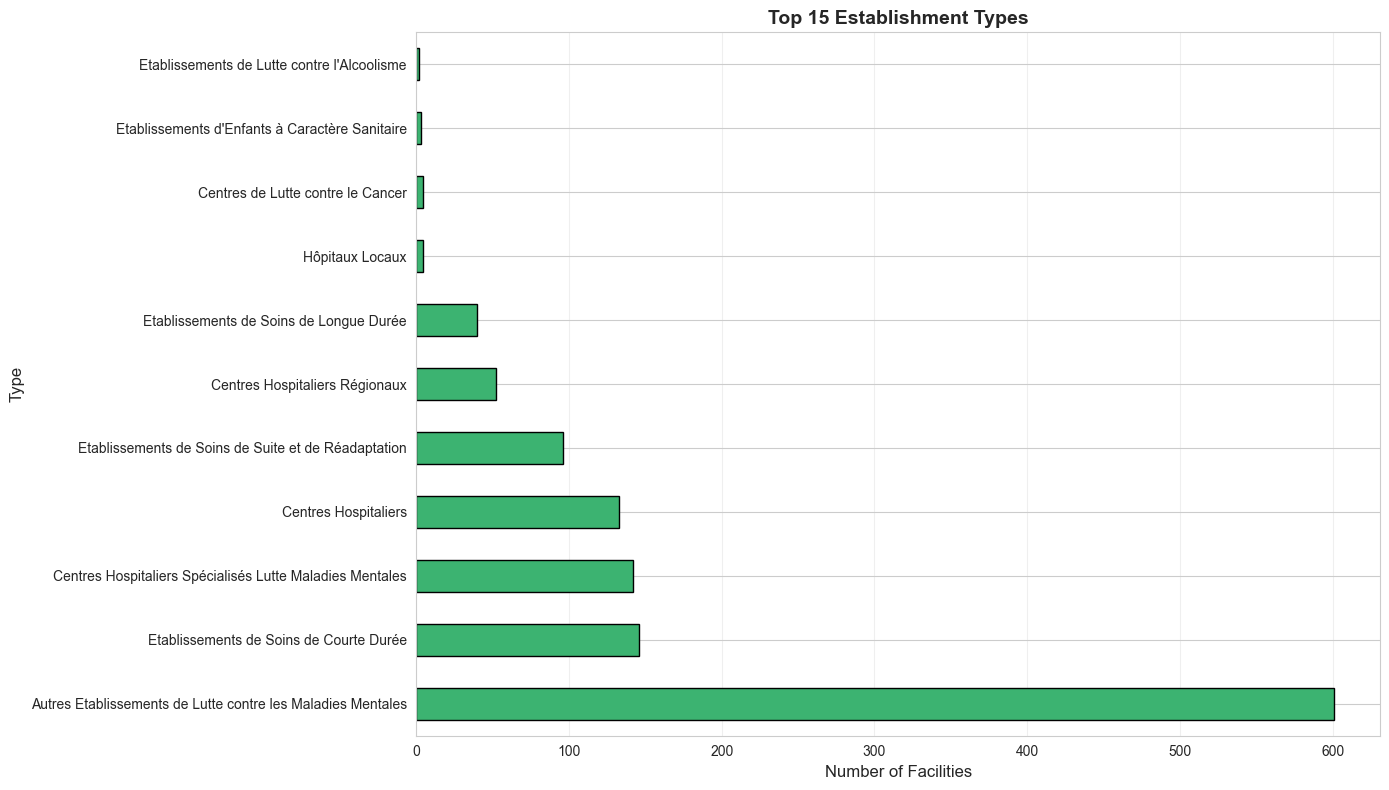

In [14]:
# Type of establishment
if 'type_etablissement' in df.columns:
    print("=" * 100)
    print("DISTRIBUTION BY ESTABLISHMENT TYPE")
    print("=" * 100)
    
    type_dist = df['type_etablissement'].value_counts().head(15)
    print(type_dist)
    
    plt.figure(figsize=(14, 8))
    type_dist.plot(kind='barh', color='mediumseagreen', edgecolor='black')
    plt.title('Top 15 Establishment Types', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Facilities', fontsize=12)
    plt.ylabel('Type', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

PUBLIC HOSPITAL SERVICE PARTICIPATION
participant_service_public_hospitalier
Etablissement public de santé                                   835
Non concerné                                                    189
Etablissement de santé privé d’intérêt collectif                113
Etab de santé privé non lucratif, non déclar intérêt collect     77
indéterminé                                                       2
Name: count, dtype: int64


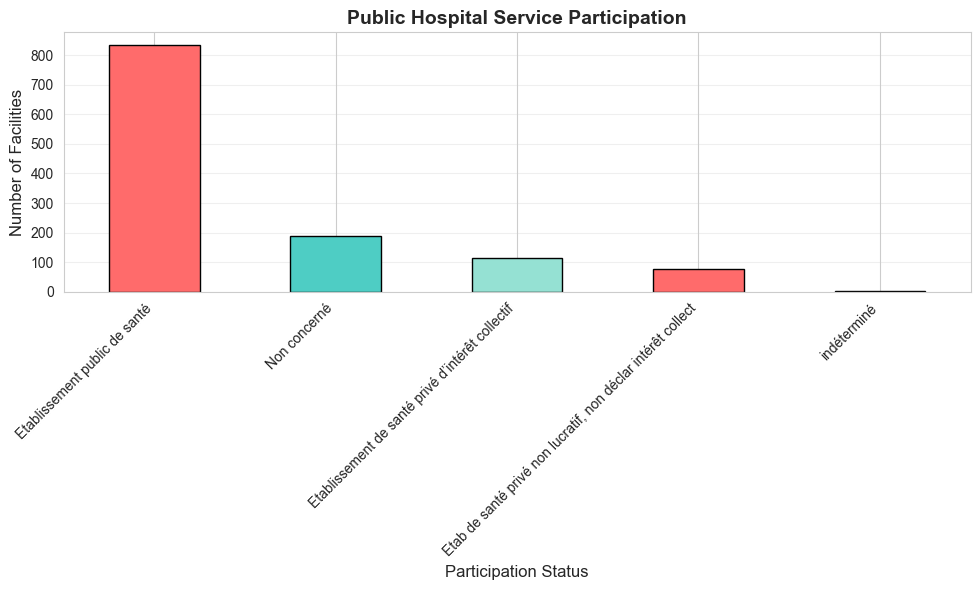

In [15]:
# Public service participation
if 'participant_service_public_hospitalier' in df.columns:
    print("=" * 100)
    print("PUBLIC HOSPITAL SERVICE PARTICIPATION")
    print("=" * 100)
    
    psph_dist = df['participant_service_public_hospitalier'].value_counts()
    print(psph_dist)
    
    plt.figure(figsize=(10, 6))
    psph_dist.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#95E1D3'], edgecolor='black')
    plt.title('Public Hospital Service Participation', fontsize=14, fontweight='bold')
    plt.xlabel('Participation Status', fontsize=12)
    plt.ylabel('Number of Facilities', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

TARIFICATION TYPES
lib_tarification
ARS établissements Publics de santé dotation globale         747
ARS établissements de santé non financés dotation globale    203
ARS établissements PSPH dotation globale                      95
ARS privé hors PSPH sous dotation globale                     70
Autorité Ministérielle                                        65
Autorité mixte ARS PCG  dotation globale                      23
Autorité mixte ARS PCG  EHPAD tripartite DG partielle          4
Tarif d'Autorité                                               4
Indéterminé                                                    3
Autorité mixte préfet dpt PCG EHPAD tripartite DG global       3
Préfet de Département établissements médico-sociaux            2
Etablissement Tarif Libre                                      2
Autorité mixte ARS PCG  EHPAD tripartite DG global             2
Name: count, dtype: int64


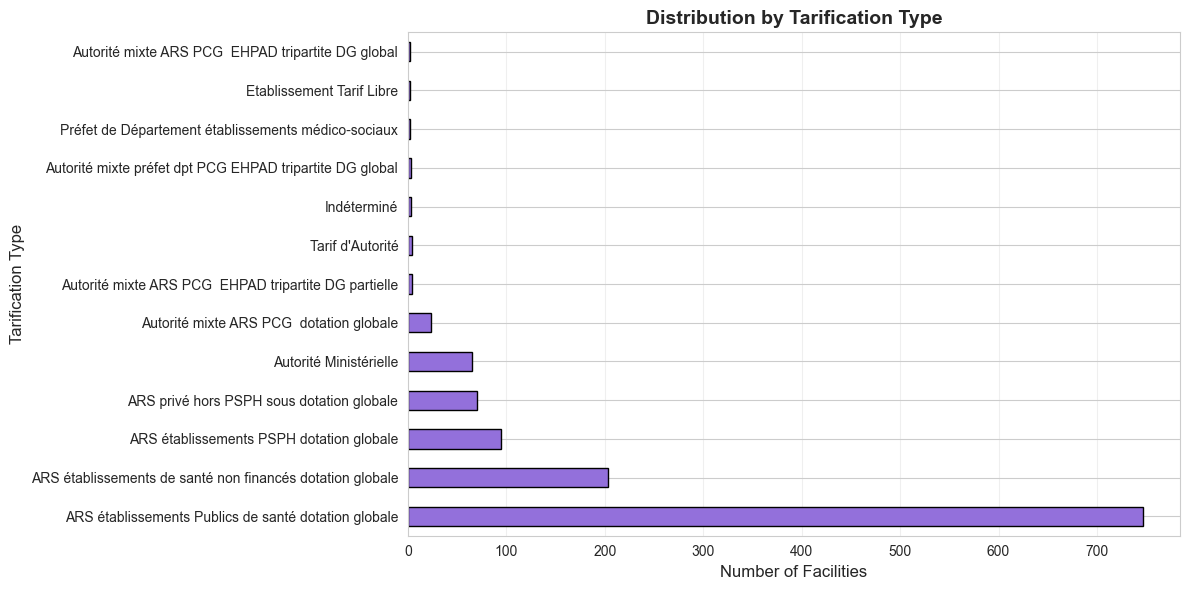

In [16]:
# Tarification type
if 'lib_tarification' in df.columns:
    print("=" * 100)
    print("TARIFICATION TYPES")
    print("=" * 100)
    
    tarif_dist = df['lib_tarification'].value_counts()
    print(tarif_dist)
    
    plt.figure(figsize=(12, 6))
    tarif_dist.plot(kind='barh', color='mediumpurple', edgecolor='black')
    plt.title('Distribution by Tarification Type', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Facilities', fontsize=12)
    plt.ylabel('Tarification Type', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 4.4 Temporal Analysis

OPENING DATE STATISTICS
Earliest opening: 1884-04-01 00:00:00
Latest opening: 2012-11-19 00:00:00
Missing dates: 0


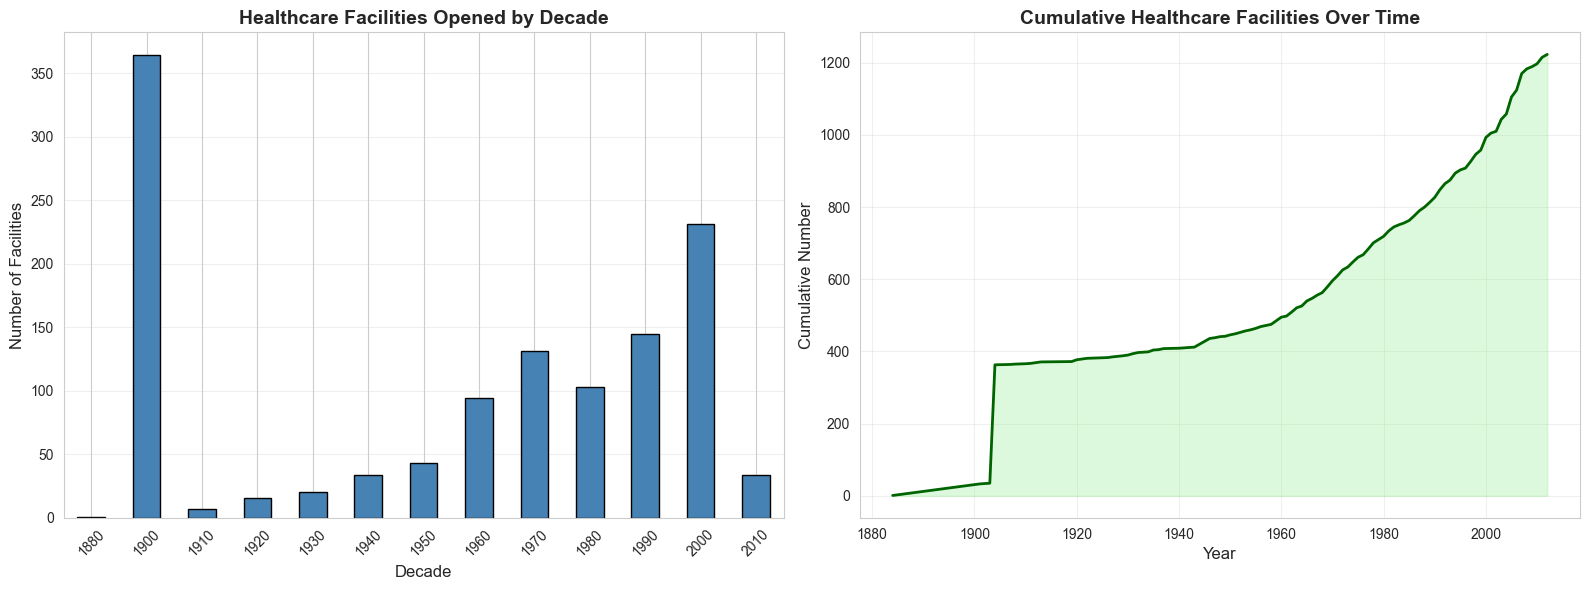

In [17]:
# Opening date analysis
if 'date_ouverture' in df.columns:
    # Convert to datetime
    df['date_ouverture_dt'] = pd.to_datetime(df['date_ouverture'], errors='coerce')
    df['year_ouverture'] = df['date_ouverture_dt'].dt.year
    df['decade_ouverture'] = (df['year_ouverture'] // 10) * 10
    
    print("=" * 100)
    print("OPENING DATE STATISTICS")
    print("=" * 100)
    print(f"Earliest opening: {df['date_ouverture_dt'].min()}")
    print(f"Latest opening: {df['date_ouverture_dt'].max()}")
    print(f"Missing dates: {df['date_ouverture_dt'].isnull().sum()}")
    
    # Plot by decade
    decade_dist = df['decade_ouverture'].value_counts().sort_index()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # By decade
    decade_dist.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
    ax1.set_title('Healthcare Facilities Opened by Decade', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Decade', fontsize=12)
    ax1.set_ylabel('Number of Facilities', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    # Cumulative
    year_dist = df['year_ouverture'].value_counts().sort_index()
    cumulative = year_dist.cumsum()
    ax2.plot(cumulative.index, cumulative.values, linewidth=2, color='darkgreen')
    ax2.fill_between(cumulative.index, cumulative.values, alpha=0.3, color='lightgreen')
    ax2.set_title('Cumulative Healthcare Facilities Over Time', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Year', fontsize=12)
    ax2.set_ylabel('Cumulative Number', fontsize=12)
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 4.5 Geographic Analysis

GEOGRAPHIC COORDINATES STATISTICS

Latitude:
count    1223.000000
mean       48.835607
std         0.132301
min        48.262183
25%        48.792876
50%        48.850071
75%        48.910656
max        49.154970
Name: lat_num, dtype: float64

Longitude:
count    1223.000000
mean        2.348229
std         0.224751
min         1.600489
25%         2.250823
50%         2.340938
75%         2.447110
max         3.316633
Name: lng_num, dtype: float64

Missing coordinates: 0


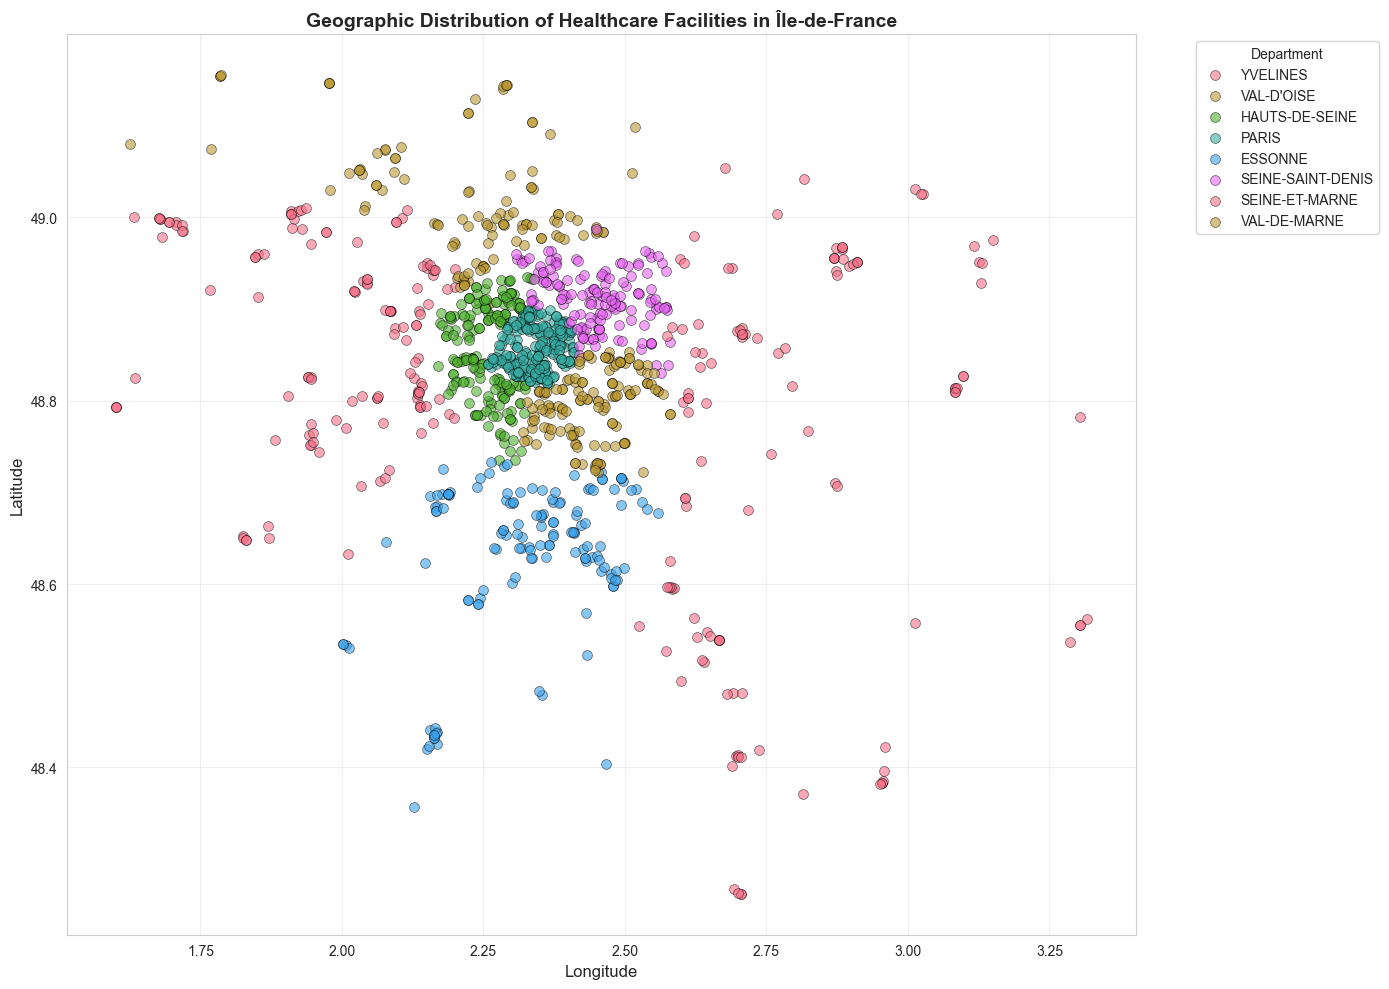

In [18]:
# Geographic coordinates analysis
if 'lat' in df.columns and 'lng' in df.columns:
    print("=" * 100)
    print("GEOGRAPHIC COORDINATES STATISTICS")
    print("=" * 100)
    
    # Convert to numeric
    df['lat_num'] = pd.to_numeric(df['lat'], errors='coerce')
    df['lng_num'] = pd.to_numeric(df['lng'], errors='coerce')
    
    print(f"\nLatitude:")
    print(df['lat_num'].describe())
    print(f"\nLongitude:")
    print(df['lng_num'].describe())
    print(f"\nMissing coordinates: {df['lat_num'].isnull().sum()}")
    
    # Map visualization
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Plot by department
    if 'dept' in df.columns:
        for dept in df['dept'].unique():
            dept_data = df[df['dept'] == dept]
            ax.scatter(dept_data['lng_num'], dept_data['lat_num'], 
                      alpha=0.6, s=50, label=dept, edgecolors='black', linewidth=0.5)
    else:
        ax.scatter(df['lng_num'], df['lat_num'], alpha=0.5, s=50, 
                  color='steelblue', edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title('Geographic Distribution of Healthcare Facilities in Île-de-France', 
                fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    if 'dept' in df.columns:
        ax.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

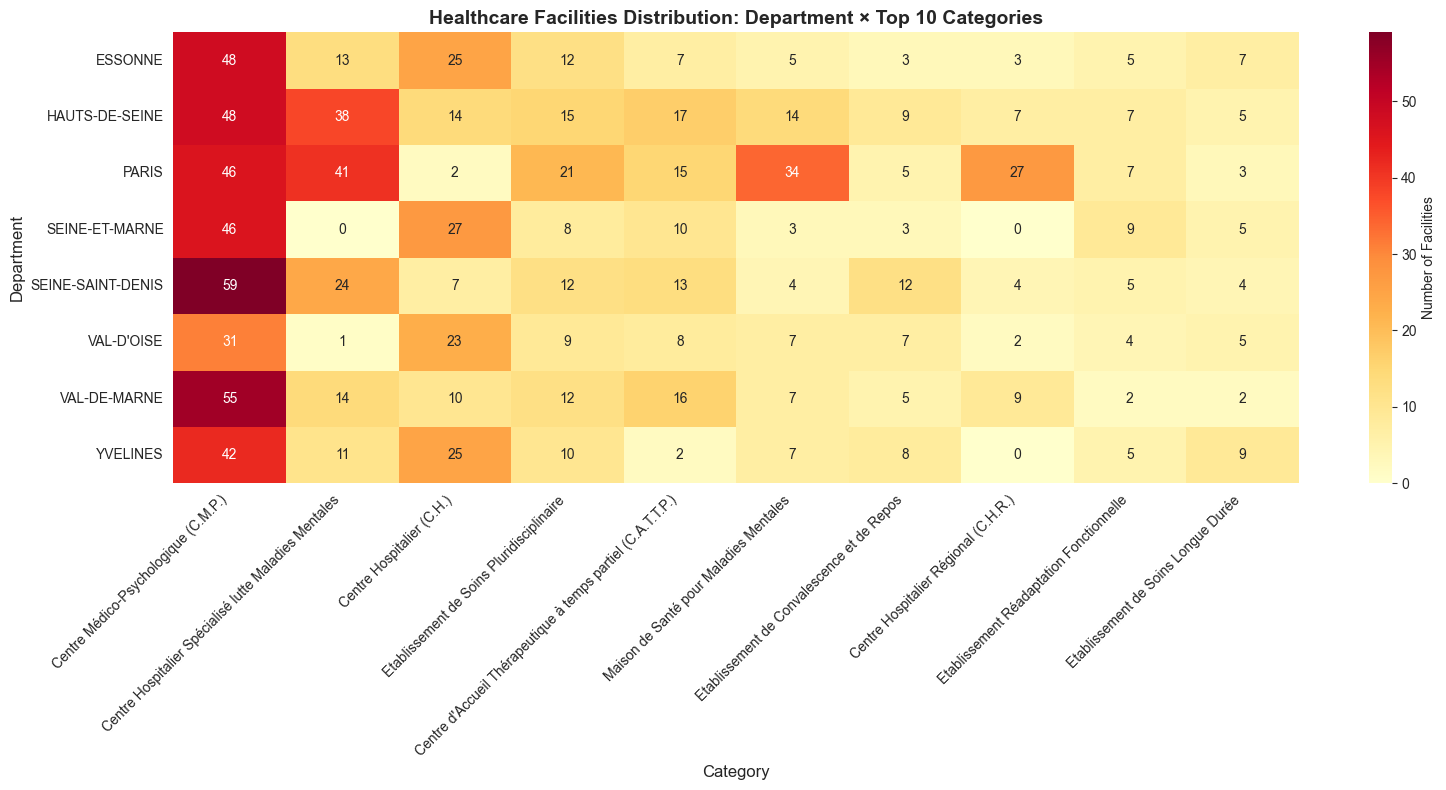

In [19]:
# Heatmap by department and category
if 'dept' in df.columns and 'categorie_de_l_etablissement' in df.columns:
    # Get top categories
    top_cats = df['categorie_de_l_etablissement'].value_counts().head(10).index
    
    # Create crosstab
    heatmap_data = pd.crosstab(df['dept'], df['categorie_de_l_etablissement'])
    heatmap_data = heatmap_data[top_cats]
    
    plt.figure(figsize=(16, 8))
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', 
                cbar_kws={'label': 'Number of Facilities'})
    plt.title('Healthcare Facilities Distribution: Department × Top 10 Categories', 
             fontsize=14, fontweight='bold')
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('Department', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 4.6 Address Analysis

In [20]:
# Complete address availability
address_cols = ['adresse_complete', 'num_voie', 'type_voie', 'voie', 'cp_ville']
existing_addr_cols = [col for col in address_cols if col in df.columns]

if existing_addr_cols:
    print("=" * 100)
    print("ADDRESS COMPLETENESS ANALYSIS")
    print("=" * 100)
    
    for col in existing_addr_cols:
        complete = df[col].notna().sum()
        pct = (complete / len(df)) * 100
        print(f"{col:<25}: {complete:>6,} / {len(df):,} ({pct:>5.1f}%)")

ADDRESS COMPLETENESS ANALYSIS
adresse_complete         :  1,221 / 1,223 ( 99.8%)
num_voie                 :  1,156 / 1,223 ( 94.5%)
type_voie                :  1,207 / 1,223 ( 98.7%)
voie                     :  1,221 / 1,223 ( 99.8%)
cp_ville                 :  1,223 / 1,223 (100.0%)



TOP 15 STREET TYPES
type_voie
R       753
AV      208
BD       83
PL       41
ALL      34
RTE      19
SQ       12
CHE      10
QU        6
PAS       4
CITE      4
VLA       4
QUA       4
RLE       3
COUR      3
Name: count, dtype: int64


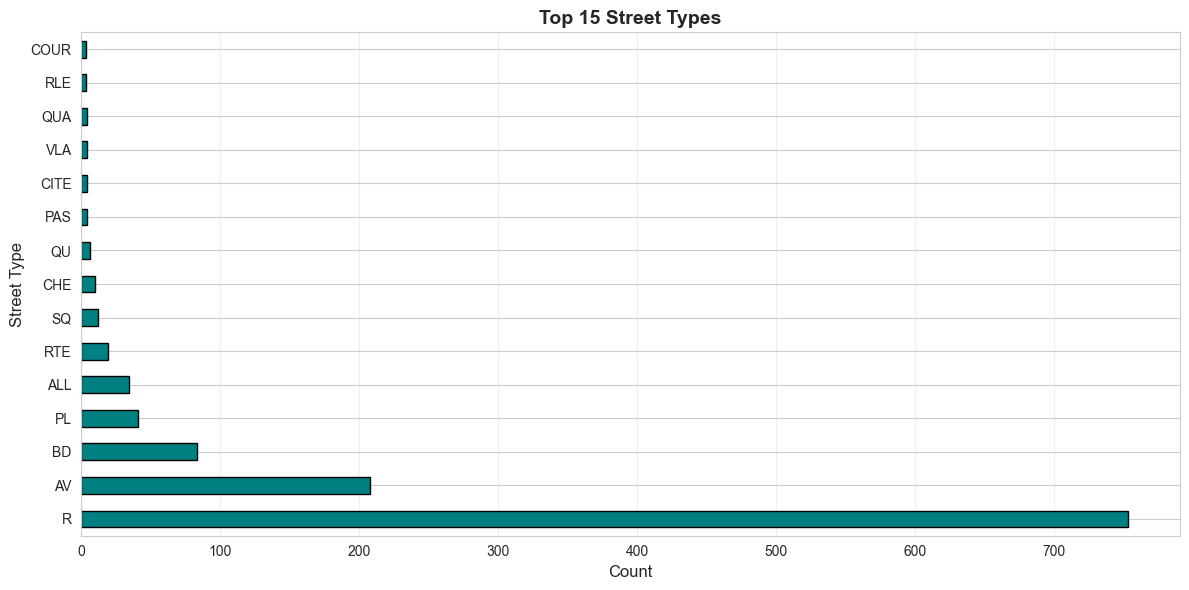

In [21]:
# Top street types
if 'type_voie' in df.columns:
    print("\n" + "=" * 100)
    print("TOP 15 STREET TYPES")
    print("=" * 100)
    
    type_voie_dist = df['type_voie'].value_counts().head(15)
    print(type_voie_dist)
    
    plt.figure(figsize=(12, 6))
    type_voie_dist.plot(kind='barh', color='teal', edgecolor='black')
    plt.title('Top 15 Street Types', fontsize=14, fontweight='bold')
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Street Type', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 4.7 Statistical Summary

In [22]:
# Numeric columns summary
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 0:
    print("=" * 100)
    print("NUMERIC FEATURES SUMMARY")
    print("=" * 100)
    display(df[numeric_cols].describe())

NUMERIC FEATURES SUMMARY


,finess_et,finess_ej,num_voie,num_dept,num_cat,num_type,num_siret,code_tarif,code_psph,lat,lng,year_ouverture,decade_ouverture,lat_num,lng_num
count,1.223000e+03,1.223000e+03,1156.000000,1223.000000,1223.000000,1223.000000,1.087000e+03,1223.000000,1216.000000,1223.000000,1223.000000,1223.000000,1223.000000,1223.000000,1223.000000
mean,8.633225e+08,8.479902e+08,41.491349,86.298446,242.838921,1108.134914,3.684180e+13,5.022077,1.702303,48.835607,2.348229,1959.290270,1955.126738,48.835607,2.348229
std,8.213321e+07,1.017153e+08,130.960755,8.213202,112.181950,3.748512,1.852776e+13,5.992658,2.091376,0.132301,0.224751,40.748741,40.517877,0.132301,0.224751
min,7.500001e+08,3.100212e+08,1.000000,75.000000,101.000000,1101.000000,1.800360e+13,1.000000,0.000000,48.262183,1.600489,1884.000000,1880.000000,48.262183,1.600489
25%,7.703003e+08,7.508059e+08,6.000000,77.000000,156.000000,1103.000000,2.691000e+13,3.000000,1.000000,48.792876,2.250823,1904.000000,1900.000000,48.792876,2.250823
50%,9.108112e+08,9.100194e+08,17.000000,91.000000,161.000000,1110.000000,2.693012e+13,3.000000,1.000000,48.850071,2.340938,1972.000000,1970.000000,48.850071,2.340938
75%,9.307009e+08,9.301400e+08,41.000000,93.000000,355.000000,1111.000000,3.840493e+13,7.000000,1.000000,48.910656,2.447110,1997.000000,1990.000000,48.910656,2.447110
max,9.508093e+08,9.508057e+08,3133.000000,95.000000,444.000000,1113.000000,9.722021e+13,99.000000,9.000000,49.154970,3.316633,2012.000000,2010.000000,49.154970,3.316633


### 4.8 Duplicate Analysis

In [23]:
# Check for duplicates
print("=" * 100)
print("DUPLICATE ANALYSIS")
print("=" * 100)

# Full row duplicates
full_dupes = df.duplicated().sum()
print(f"\nFull row duplicates: {full_dupes:,}")

# FINESS duplicates (should be unique)
if 'finess_et' in df.columns:
    finess_dupes = df['finess_et'].duplicated().sum()
    print(f"Duplicate FINESS ET codes: {finess_dupes:,}")
    
    if finess_dupes > 0:
        print("\nDuplicate FINESS ET examples:")
        dupe_finess = df[df['finess_et'].duplicated(keep=False)].sort_values('finess_et')
        display(dupe_finess[['finess_et', 'raison_sociale', 'adresse_complete', 'dept']].head(10))

# Address duplicates
if 'adresse_complete' in df.columns:
    addr_dupes = df['adresse_complete'].duplicated().sum()
    print(f"\nDuplicate addresses: {addr_dupes:,}")

DUPLICATE ANALYSIS

Full row duplicates: 0
Duplicate FINESS ET codes: 0

Duplicate addresses: 113


## 5. Data Cleaning

In [24]:
# Create a copy for cleaning
df_clean = df.copy()

print("=" * 100)
print("STARTING DATA CLEANING PROCESS")
print("=" * 100)
print(f"\nInitial shape: {df_clean.shape}")
print(f"Initial memory: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

STARTING DATA CLEANING PROCESS

Initial shape: (1223, 36)
Initial memory: 1.76 MB


### 5.1 Remove Full Duplicates

In [25]:
# Remove complete duplicate rows
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
removed_dupes = initial_rows - len(df_clean)

print(f"Removed {removed_dupes:,} duplicate rows")
print(f"Remaining rows: {len(df_clean):,}")

Removed 0 duplicate rows
Remaining rows: 1,223


### 5.2 Handle FINESS Duplicates

In [26]:
# Keep only the first occurrence of duplicate FINESS codes
if 'finess_et' in df_clean.columns:
    initial_rows = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['finess_et'], keep='first')
    removed_finess_dupes = initial_rows - len(df_clean)
    
    print(f"\nRemoved {removed_finess_dupes:,} duplicate FINESS ET records (kept first occurrence)")
    print(f"Remaining rows: {len(df_clean):,}")


Removed 0 duplicate FINESS ET records (kept first occurrence)
Remaining rows: 1,223


### 5.3 Data Type Corrections

In [27]:
# Fix data types
print("\n" + "="*100)
print("CORRECTING DATA TYPES")
print("="*100)

# FINESS codes (keep as string with leading zeros)
for col in ['finess_et', 'finess_ej']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()
        print(f"✓ {col}: converted to string")

# Numeric codes
numeric_code_cols = ['num_dept', 'num_cat', 'num_type', 'code_psph', 'code_tarif']
for col in numeric_code_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        print(f"✓ {col}: converted to numeric")

# Coordinates
for col in ['lat', 'lng']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        print(f"✓ {col}: converted to float")

# Date
if 'date_ouverture' in df_clean.columns:
    df_clean['date_ouverture'] = pd.to_datetime(df_clean['date_ouverture'], errors='coerce')
    print(f"✓ date_ouverture: converted to datetime")

# Postal code
if 'cp_ville' in df_clean.columns:
    # Extract postal code (first 5 digits)
    df_clean['code_postal'] = df_clean['cp_ville'].str.extract(r'(\d{5})')[0]
    print(f"✓ code_postal: extracted from cp_ville")


CORRECTING DATA TYPES
✓ finess_et: converted to string
✓ finess_ej: converted to string
✓ num_dept: converted to numeric
✓ num_cat: converted to numeric
✓ num_type: converted to numeric
✓ code_psph: converted to numeric
✓ code_tarif: converted to numeric
✓ lat: converted to float
✓ lng: converted to float
✓ date_ouverture: converted to datetime
✓ code_postal: extracted from cp_ville


### 5.4 Clean String Data

In [28]:
# Clean all string columns
print("\n" + "="*100)
print("CLEANING STRING DATA")
print("="*100)

string_cols = df_clean.select_dtypes(include=['object']).columns

for col in string_cols:
    if col not in ['date_ouverture']:  # Skip already converted columns
        # Strip whitespace
        df_clean[col] = df_clean[col].astype(str).str.strip()
        
        # Remove multiple spaces
        df_clean[col] = df_clean[col].str.replace(r'\s+', ' ', regex=True)
        
        # Replace 'nan' string with actual NaN
        df_clean.loc[df_clean[col] == 'nan', col] = np.nan

print(f"✓ Cleaned {len(string_cols)} string columns")


CLEANING STRING DATA
✓ Cleaned 22 string columns


### 5.5 Handle Missing Values

In [36]:
print("\n" + "="*100)
print("HANDLING MISSING VALUES")
print("="*100)

# Strategy:
# 1. Drop columns with >70% missing (if not essential)
# 2. Fill categorical with 'Non renseigné'
# 3. Keep numeric NaN as is (or fill with appropriate value)

missing_threshold = 70

# Identify columns to potentially drop
missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
cols_high_missing = missing_pct[missing_pct > missing_threshold].index.tolist()

# Essential columns to keep regardless of missing values
essential_cols = ['finess_et', 'finess_ej', 'raison_sociale', 'lat', 'lng', 
                 'dept', 'categorie_de_l_etablissement', 'type_etablissement']

cols_to_drop = [col for col in cols_high_missing if col not in essential_cols]

if cols_to_drop:
    print(f"\nDropping {len(cols_to_drop)} columns with >{missing_threshold}% missing:")
    for col in cols_to_drop:
        pct = missing_pct[col]
        print(f"  - {col}: {pct:.1f}% missing")
    df_clean = df_clean.drop(cols_to_drop, axis=1)
else:
    print(f"\nNo columns exceed {missing_threshold}% missing threshold")

# Fill categorical missing values
categorical_fill_cols = ['adresse_administrative_2', 'complement_adresse', 'num_fax']
for col in categorical_fill_cols:
    if col in df_clean.columns:
        df_clean[col].fillna('Non renseigné', inplace=True)
        print(f"✓ Filled '{col}' with 'Non renseigné'")

# Fill numeric street number
if 'num_voie' in df_clean.columns:
    df_clean['num_voie'].fillna(None, inplace=True)
    print(f"✓ Filled 'num_voie' with empty string")


HANDLING MISSING VALUES

No columns exceed 70% missing threshold
✓ Filled 'num_fax' with 'Non renseigné'
✓ Filled 'num_voie' with empty string


### 5.6 Create Derived Features

In [37]:
print("\n" + "="*100)
print("CREATING DERIVED FEATURES")
print("="*100)

# Extract year, decade from opening date
if 'date_ouverture' in df_clean.columns:
    df_clean['annee_ouverture'] = df_clean['date_ouverture'].dt.year
    df_clean['decennie_ouverture'] = (df_clean['annee_ouverture'] // 10) * 10
    df_clean['age_etablissement'] = 2024 - df_clean['annee_ouverture']
    print("✓ Created: annee_ouverture, decennie_ouverture, age_etablissement")

# Create full address if not exists
if 'adresse_complete' not in df_clean.columns or df_clean['adresse_complete'].isnull().sum() > 0:
    if all(col in df_clean.columns for col in ['num_voie', 'type_voie', 'voie']):
        df_clean['adresse_reconstituee'] = (
            df_clean['num_voie'].astype(str) + ' ' + 
            df_clean['type_voie'].astype(str) + ' ' + 
            df_clean['voie'].astype(str)
        ).str.strip()
        print("✓ Created: adresse_reconstituee")

# Department number
if 'code_postal' in df_clean.columns:
    df_clean['num_dept_from_cp'] = df_clean['code_postal'].str[:2]
    print("✓ Created: num_dept_from_cp")

# Binary flags
if 'participant_service_public_hospitalier' in df_clean.columns:
    df_clean['is_public_service'] = df_clean['participant_service_public_hospitalier'].apply(
        lambda x: 1 if x == 'Etablissement public de santé' else 0
    )
    print("✓ Created: is_public_service (binary flag)")

# Has coordinates flag
if 'lat' in df_clean.columns and 'lng' in df_clean.columns:
    df_clean['has_coordinates'] = df_clean['lat'].notna() & df_clean['lng'].notna()
    print("✓ Created: has_coordinates (binary flag)")


CREATING DERIVED FEATURES
✓ Created: annee_ouverture, decennie_ouverture, age_etablissement
✓ Created: adresse_reconstituee
✓ Created: num_dept_from_cp
✓ Created: is_public_service (binary flag)
✓ Created: has_coordinates (binary flag)


### 5.7 Standardize Categorical Values

In [38]:
print("\n" + "="*100)
print("STANDARDIZING CATEGORICAL VALUES")
print("="*100)

# Standardize department names (capitalize)
if 'dept' in df_clean.columns:
    df_clean['dept'] = df_clean['dept'].str.upper()
    print("✓ Standardized department names to uppercase")

# Standardize establishment names (title case)
if 'raison_sociale' in df_clean.columns:
    # Keep original but clean
    df_clean['raison_sociale'] = df_clean['raison_sociale'].str.strip()
    print("✓ Cleaned establishment names")


STANDARDIZING CATEGORICAL VALUES
✓ Standardized department names to uppercase
✓ Cleaned establishment names


### 5.8 Validate Coordinates

In [39]:
# Validate geographic coordinates for Île-de-France region
print("\n" + "="*100)
print("VALIDATING GEOGRAPHIC COORDINATES")
print("="*100)

if 'lat' in df_clean.columns and 'lng' in df_clean.columns:
    # Île-de-France approximate bounds
    lat_min, lat_max = 48.1, 49.3
    lng_min, lng_max = 1.4, 3.6
    
    # Find invalid coordinates
    invalid_coords = df_clean[
        (df_clean['lat'].notna()) & (df_clean['lng'].notna()) &
        ((df_clean['lat'] < lat_min) | (df_clean['lat'] > lat_max) |
         (df_clean['lng'] < lng_min) | (df_clean['lng'] > lng_max))
    ]
    
    print(f"Found {len(invalid_coords)} facilities with coordinates outside Île-de-France bounds")
    
    if len(invalid_coords) > 0:
        print("\nInvalid coordinate examples:")
        display(invalid_coords[['finess_et', 'raison_sociale', 'lat', 'lng', 'dept']].head())
        
        # Optionally set invalid coordinates to NaN
        # df_clean.loc[invalid_coords.index, ['lat', 'lng']] = np.nan
    else:
        print("✓ All coordinates are within valid Île-de-France bounds")


VALIDATING GEOGRAPHIC COORDINATES
Found 0 facilities with coordinates outside Île-de-France bounds
✓ All coordinates are within valid Île-de-France bounds


### 5.9 Final Quality Check

In [40]:
print("\n" + "="*100)
print("FINAL DATA QUALITY REPORT")
print("="*100)

print(f"\n📊 Dataset Dimensions:")
print(f"  Rows: {len(df_clean):,}")
print(f"  Columns: {df_clean.shape[1]}")
print(f"  Memory: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n🔍 Missing Values:")
total_missing = df_clean.isnull().sum().sum()
print(f"  Total: {total_missing:,}")

if total_missing > 0:
    print(f"\n  By Column:")
    missing_by_col = df_clean.isnull().sum()
    missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)
    for col, count in missing_by_col.items():
        pct = (count / len(df_clean)) * 100
        print(f"    {col:<40}: {count:>6,} ({pct:>5.1f}%)")

print(f"\n🔄 Duplicates:")
print(f"  Full row duplicates: {df_clean.duplicated().sum()}")
if 'finess_et' in df_clean.columns:
    print(f"  Duplicate FINESS codes: {df_clean['finess_et'].duplicated().sum()}")

print(f"\n📍 Geographic Coverage:")
if 'lat' in df_clean.columns and 'lng' in df_clean.columns:
    coords_available = (df_clean['lat'].notna() & df_clean['lng'].notna()).sum()
    coords_pct = (coords_available / len(df_clean)) * 100
    print(f"  Facilities with coordinates: {coords_available:,} ({coords_pct:.1f}%)")

if 'dept' in df_clean.columns:
    print(f"  Departments covered: {df_clean['dept'].nunique()}")
    print(f"  Distribution: {df_clean['dept'].value_counts().to_dict()}")


FINAL DATA QUALITY REPORT

📊 Dataset Dimensions:
  Rows: 1,223
  Columns: 40
  Memory: 1.76 MB

🔍 Missing Values:
  Total: 1,965

  By Column:
    code_ape                                :    582 ( 47.6%)
    raison_sociale_entite_juridique         :    553 ( 45.2%)
    num_fax                                 :    421 ( 34.4%)
    num_siret                               :    136 ( 11.1%)
    num_tel                                 :     92 (  7.5%)
    adresse_reconstituee                    :     80 (  6.5%)
    num_voie                                :     67 (  5.5%)
    type_voie                               :     16 (  1.3%)
    participant_service_public_hospitalier  :      7 (  0.6%)
    code_psph                               :      7 (  0.6%)
    voie                                    :      2 (  0.2%)
    adresse_complete                        :      2 (  0.2%)

🔄 Duplicates:
  Full row duplicates: 0
  Duplicate FINESS codes: 0

📍 Geographic Coverage:
  Facilities with co

In [41]:
# Display cleaned data sample
print("\n" + "="*100)
print("CLEANED DATA SAMPLE")
print("="*100)
display(df_clean.head(10))


CLEANED DATA SAMPLE


,finess_et,finess_ej,raison_sociale,raison_sociale_entite_juridique,num_voie,type_voie,voie,adresse_complete,num_dept,dept,cp_ville,num_tel,num_fax,num_cat,categorie_de_l_etablissement,num_type,type_etablissement,num_siret,code_ape,code_tarif,lib_tarification,code_psph,participant_service_public_hospitalier,date_ouverture,lat,lng,wgs84,date_ouverture_dt,year_ouverture,decade_ouverture,lat_num,lng_num,code_postal,annee_ouverture,decennie_ouverture,age_etablissement,adresse_reconstituee,num_dept_from_cp,is_public_service,has_coordinates
0,780420048,780021069,REPOS ET CONVALESCENCE L'OASIS,NaN,NaN,R,LAMARTINE,R LAMARTINE,78,YVELINES,78470 ST REMY LES CHEVREUSE,01 30 47 80 00,01 30 47 80 12,108,Etablissement de Convalescence et de Repos,1107,Etablissements de Soins de Suite et de Réadapt...,4.445168e+13,8610Z,7,ARS établissements de santé non financés dotat...,0.0,Non concerné,1946-01-05,48.711967,2.068011,"48.7119665,2.0680105",1946-01-05,1946,1940,48.711967,2.068011,78470,1946,1940,78,NaN,78,0,True
1,780017901,780140059,CENTRE ARMAGIS,NaN,9.0,R,ARMAGIS,9 R ARMAGIS,78,YVELINES,78100 ST GERMAIN EN LAYE,01 39 21 14 35,NaN,156,Centre Médico-Psychologique (C.M.P.),1111,Autres Etablissements de Lutte contre les Mala...,NaN,NaN,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,1997-01-01,48.897809,2.085892,"48.8978094,2.0858916",1997-01-01,1997,1990,48.897809,2.085892,78100,1997,1990,27,9.0 R ARMAGIS,78,1,True
2,780018289,780110078,CMP ADOLESCENTS 78I06,NaN,11.0,R,JOUVENCEL,11B R JOUVENCEL,78,YVELINES,78000 VERSAILLES,01 39 63 90 91,NaN,156,Centre Médico-Psychologique (C.M.P.),1111,Autres Etablissements de Lutte contre les Mala...,NaN,NaN,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,2007-01-29,48.803140,2.133176,"48.8031397,2.1331757",2007-01-29,2007,2000,48.803140,2.133176,78000,2007,2000,17,11.0 R JOUVENCEL,78,1,True
3,950006619,950110015,CENTRE DE JOUR DU FIEF,NaN,45.0,R,DU FIEF,45 R DU FIEF,95,VAL-D'OISE,95100 ARGENTEUIL,NaN,NaN,355,Centre Hospitalier (C.H.),1102,Centres Hospitaliers,2.695016e+13,8610Z,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,2005-01-01,48.950513,2.237513,"48.9505132,2.237513",2005-01-01,2005,2000,48.950513,2.237513,95100,2005,2000,19,45.0 R DU FIEF,95,1,True
4,920812013,780140059,CMP ENFANTS 92I02 (J. PREVERT),CENTRE MEDICO PSYCHOLOGIQUE INFANTO-JUVENILE,2.0,PAS,JACQUES PREVERT,2 PAS JACQUES PREVERT,92,HAUTS-DE-SEINE,92700 COLOMBES,01 47 82 37 34,01 47 82 88 30,156,Centre Médico-Psychologique (C.M.P.),1111,Autres Etablissements de Lutte contre les Mala...,2.678024e+13,NaN,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,1904-04-04,48.922089,2.252624,"48.9220894,2.252624",1904-04-04,1904,1900,48.922089,2.252624,92700,1904,1900,120,2.0 PAS JACQUES PREVERT,92,1,True
5,920024676,950140012,CMP ADULTES 92G04 (C. DESMOULIN),NaN,7.0,R,CAMILLE DESMOULIN,7 R CAMILLE DESMOULIN,92,HAUTS-DE-SEINE,92300 LEVALLOIS PERRET,01 41 34 07 30,NaN,156,Centre Médico-Psychologique (C.M.P.),1111,Autres Etablissements de Lutte contre les Mala...,2.695001e+13,NaN,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,1998-01-01,48.888899,2.284317,"48.8888994,2.2843171",1998-01-01,1998,1990,48.888899,2.284317,92300,1998,1990,26,7.0 R CAMILLE DESMOULIN,92,1,True
6,920810827,940140049,CMP BAGNEUX,NaN,64.0,R,DES MEUNIERS,64 R DES MEUNIERS,92,HAUTS-DE-SEINE,92220 BAGNEUX,01 46 63 45 50,01 46 63 82 84,156,Centre Médico-Psychologique (C.M.P.),1111,Autres Etablissements de Lutte contre les Mala...,2.692014e+13,8610Z,3,ARS établissements Publics de santé dotation g...,1.0,Etablissement public de santé,1904-04-04,48.797786,2.315253,"48.7977862,2.3152535",1904-04-04,1904,1900,48.797786,2.315253,92220,1904,1900,120,64.0 R DES MEUNIERS,92,1,True
7,920002177,920804465,ETABLISSEMENT PUBLIC DE SANTE ERASME,NaN,143.0,AV,ARMAND GUILLEBAUD,143 AV ARMAND GUILLEBAUD,92,HAUTS-

## 6. Save Cleaned Data

In [43]:
# Save cleaned data
print("="*100)
print("SAVING CLEANED DATA")
print("="*100)

# CSV
output_csv = '/data/silver/les_etablissements_hospitaliers_franciliens_cleaned.csv'
df_clean.to_csv(output_csv, index=False, sep=';', encoding='utf-8-sig')
print(f"✓ Saved to CSV: {output_csv}")

# Excel
output_excel = '/data/silver/les_etablissements_hospitaliers_franciliens_cleaned.xlsx'
df_clean.to_excel(output_excel, index=False, engine='openpyxl')
print(f"✓ Saved to Excel: {output_excel}")

# GeoJSON (if coordinates available)
if 'lat' in df_clean.columns and 'lng' in df_clean.columns:
    try:
        import json
        
        # Filter only records with valid coordinates
        df_geo = df_clean[df_clean['lat'].notna() & df_clean['lng'].notna()].copy()
        
        # Create GeoJSON structure
        features = []
        for idx, row in df_geo.iterrows():
            feature = {
                "type": "Feature",
                "geometry": {
                    "type": "Point",
                    "coordinates": [float(row['lng']), float(row['lat'])]
                },
                "properties": {
                    "finess_et": str(row['finess_et']),
                    "raison_sociale": str(row['raison_sociale']),
                    "categorie": str(row.get('categorie_de_l_etablissement', '')),
                    "type": str(row.get('type_etablissement', '')),
                    "dept": str(row.get('dept', '')),
                    "adresse": str(row.get('adresse_complete', ''))
                }
            }
            features.append(feature)
        
        geojson = {
            "type": "FeatureCollection",
            "features": features
        }
        
        output_geojson = '/data/silver/les_etablissements_hospitaliers_franciliens.geojson'
        with open(output_geojson, 'w', encoding='utf-8') as f:
            json.dump(geojson, f, ensure_ascii=False, indent=2)
        
        print(f"✓ Saved to GeoJSON: {output_geojson}")
        print(f"  ({len(features):,} facilities with coordinates)")
    except Exception as e:
        print(f"⚠ Could not create GeoJSON: {e}")

SAVING CLEANED DATA
✓ Saved to CSV: /data/les_etablissements_hospitaliers_franciliens_cleaned.csv
✓ Saved to Excel: /data/les_etablissements_hospitaliers_franciliens_cleaned.xlsx
✓ Saved to GeoJSON: /data/les_etablissements_hospitaliers_franciliens.geojson
  (1,223 facilities with coordinates)


## 7. Generate Data Dictionary

In [44]:
# Create comprehensive data dictionary
data_dict = pd.DataFrame({
    'Column_Name': df_clean.columns,
    'Data_Type': df_clean.dtypes.astype(str).values,
    'Non_Null_Count': df_clean.count().values,
    'Null_Count': df_clean.isnull().sum().values,
    'Null_Percentage': (df_clean.isnull().sum() / len(df_clean) * 100).round(2).values,
    'Unique_Values': [df_clean[col].nunique() for col in df_clean.columns],
    'Sample_Value': [str(df_clean[col].dropna().iloc[0]) if len(df_clean[col].dropna()) > 0 else 'N/A' 
                     for col in df_clean.columns]
})

# Add descriptions (French)
descriptions = {
    'finess_et': 'Numéro FINESS de l\'établissement',
    'finess_ej': 'Numéro FINESS de l\'entité juridique',
    'raison_sociale': 'Nom de l\'établissement',
    'dept': 'Département',
    'categorie_de_l_etablissement': 'Catégorie de l\'établissement',
    'type_etablissement': 'Type d\'établissement',
    'participant_service_public_hospitalier': 'Participation au service public hospitalier',
    'date_ouverture': 'Date d\'ouverture',
    'lat': 'Latitude (WGS84)',
    'lng': 'Longitude (WGS84)',
    'adresse_complete': 'Adresse complète',
    'cp_ville': 'Code postal et ville'
}

data_dict['Description'] = data_dict['Column_Name'].map(descriptions).fillna('')

# Save data dictionary
dict_path = '/data/silver/etablissements_hospitaliers_data_dictionary.csv'
data_dict.to_csv(dict_path, index=False, encoding='utf-8-sig')
print(f"\n✓ Data dictionary saved: {dict_path}")

display(data_dict)


✓ Data dictionary saved: /data/etablissements_hospitaliers_data_dictionary.csv


,Column_Name,Data_Type,Non_Null_Count,Null_Count,Null_Percentage,Unique_Values,Sample_Value,Description
0,finess_et,str,1223,0,0.00,1223,780420048,Numéro FINESS de l'établissement
1,finess_ej,str,1223,0,0.00,315,780021069,Numéro FINESS de l'entité juridique
2,raison_sociale,str,1223,0,0.00,1127,REPOS ET CONVALESCENCE L'OASIS,Nom de l'établissement
3,raison_sociale_entite_juridique,str,670,553,45.22,603,CENTRE MEDICO PSYCHOLOGIQUE INFANTO-JUVENILE,
4,num_voie,float64,1156,67,5.48,165,9.0,
5,type_voie,str,1207,16,1.31,27,R,
6,voie,str,1221,2,0.16,856,LAMARTINE,
7,adresse_complete,str,1221,2,0.16,1108,R LAMARTINE,Adresse complète
8,num_dept,int64,1223,0,0.00,8,78,
9,dept,str,1223,0,0.00,8,YVELINES,Département


## 8. Summary Statistics

In [46]:
# Generate summary report
print("="*100)
print("FINAL SUMMARY STATISTICS")
print("="*100)

summary = {
    'Metric': [
        'Total Healthcare Facilities',
        'Total Features/Columns',
        'Numeric Features',
        'Categorical Features',
        'Departments Covered',
        'Establishment Categories',
        'Establishment Types',
        'Facilities with Coordinates',
        'Public Service Participants',
        'Oldest Facility Opening',
        'Newest Facility Opening',
        'Total Missing Values',
        'Data Completeness',
        'Memory Usage (MB)'
    ],
    'Value': [
        f"{len(df_clean):,}",
        df_clean.shape[1],
        len(df_clean.select_dtypes(include=[np.number]).columns),
        len(df_clean.select_dtypes(include=['object']).columns),
        df_clean['dept'].nunique() if 'dept' in df_clean.columns else 'N/A',
        df_clean['categorie_de_l_etablissement'].nunique() if 'categorie_de_l_etablissement' in df_clean.columns else 'N/A',
        df_clean['type_etablissement'].nunique() if 'type_etablissement' in df_clean.columns else 'N/A',
        f"{(df_clean['lat'].notna() & df_clean['lng'].notna()).sum():,}" if 'lat' in df_clean.columns else 'N/A',
        f"{(df_clean['is_public_service']==1).sum():,}" if 'is_public_service' in df_clean.columns else 'N/A',
        str(df_clean['date_ouverture'].min()) if 'date_ouverture' in df_clean.columns else 'N/A',
        str(df_clean['date_ouverture'].max()) if 'date_ouverture' in df_clean.columns else 'N/A',
        f"{df_clean.isnull().sum().sum():,}",
        f"{((1 - df_clean.isnull().sum().sum() / (len(df_clean) * df_clean.shape[1])) * 100):.2f}%",
        f"{df_clean.memory_usage(deep=True).sum() / 1024**2:.2f}"
    ]
}

summary_df = pd.DataFrame(summary)
display(summary_df)

# Save summary
summary_path = 'etablissements_hospitaliers_summary.csv'
summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')
print(f"\n✓ Summary saved: {summary_path}")

FINAL SUMMARY STATISTICS


,Metric,Value
0,Total Healthcare Facilities,"1,223"
1,Total Features/Columns,40
2,Numeric Features,17
3,Categorical Features,20
4,Departments Covered,8
5,Establishment Categories,22
6,Establishment Types,11
7,Facilities with Coordinates,"1,223"
8,Public Service Participants,835
9,Oldest Facility Opening,1884-04-01 00:00:00



✓ Summary saved: /data/etablissements_hospitaliers_summary.csv


In [74]:
# Save to csv
summary_path = 'etablissements_hospitaliers_summary.csv'
summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')